Manual Slope: 2.084160010207494e-13
Manual Intercept: 544848.2688325455
Sklearn Coef: 267.22365823732684
Sklearn Intercept: -26048.20939543005
Model saved successfully ✅


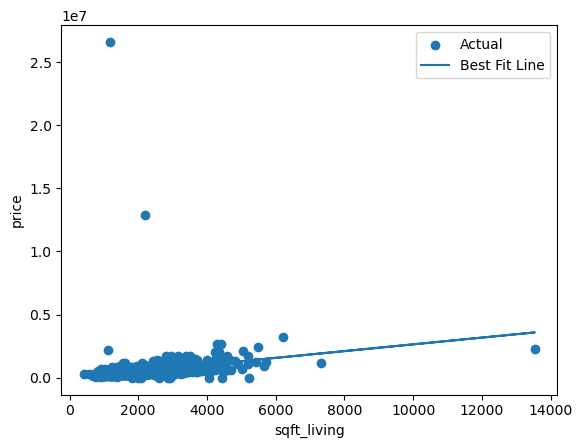

In [17]:
# ===============================
# 1. IMPORTS
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("data.csv")

# ===============================
# 3. FEATURES & TARGET
# ===============================
X = df[["sqft_living"]].values
y = df["price"].values

# ===============================
# 4. TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. MANUAL LINEAR REGRESSION
# ===============================
x_mean = np.mean(X_train)
y_mean = np.mean(y_train)

m = np.sum((X_train - x_mean)*(y_train - y_mean)) / np.sum((X_train - x_mean)**2)
b = y_mean - m*x_mean

print("Manual Slope:", m)
print("Manual Intercept:", b)

# ===============================
# 6. SKLEARN MODEL
# ===============================
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Sklearn Coef:", model.coef_[0])
print("Sklearn Intercept:", model.intercept_)

# ===============================
# 7. SAVE MODEL (FINAL STEP)
# ===============================
pickle.dump(model, open("house_price_model.pkl", "wb"))

print("Model saved successfully ✅")

# ===============================
# 8. PLOT
# ===============================
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Best Fit Line")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.legend()
plt.show()